# Eksperimen Machine Learning - Heart Disease Classification
**Nama:** Kholilah Nurafifah  
**Dataset:** Heart Disease UCI (Kaggle)  
**Tipe Masalah:** Klasifikasi Biner  
**Tujuan:** Memprediksi apakah seseorang menderita penyakit jantung atau tidak

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

print('Library berhasil diimport!')

Matplotlib is building the font cache; this may take a moment.


Library berhasil diimport!


## 2. Data Loading

In [2]:
# Load dataset Heart Disease
# Dataset: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
df = pd.read_csv('../heart.csv')

print('Shape dataset:', df.shape)
print('\nInformasi Dataset:')
df.info()

Shape dataset: (1025, 14)

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
# Tampilkan 5 baris pertama
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Statistik deskriptif
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Cek missing values
print('Missing Values per Kolom:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')

Missing Values per Kolom:
Tidak ada missing values


In [6]:
# Cek duplikat
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

Jumlah baris duplikat: 723


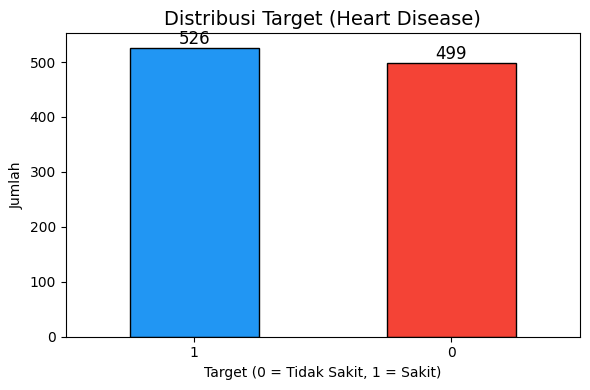


Proporsi target:
target
1    0.513
0    0.487
Name: proportion, dtype: float64


In [7]:
# Distribusi target (target)
plt.figure(figsize=(6, 4))
ax = df['target'].value_counts().plot(kind='bar', color=['#2196F3', '#F44336'], edgecolor='black')
plt.title('Distribusi Target (Heart Disease)', fontsize=14)
plt.xlabel('Target (0 = Tidak Sakit, 1 = Sakit)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=100)
plt.show()
print('\nProporsi target:')
print(df['target'].value_counts(normalize=True).round(3))

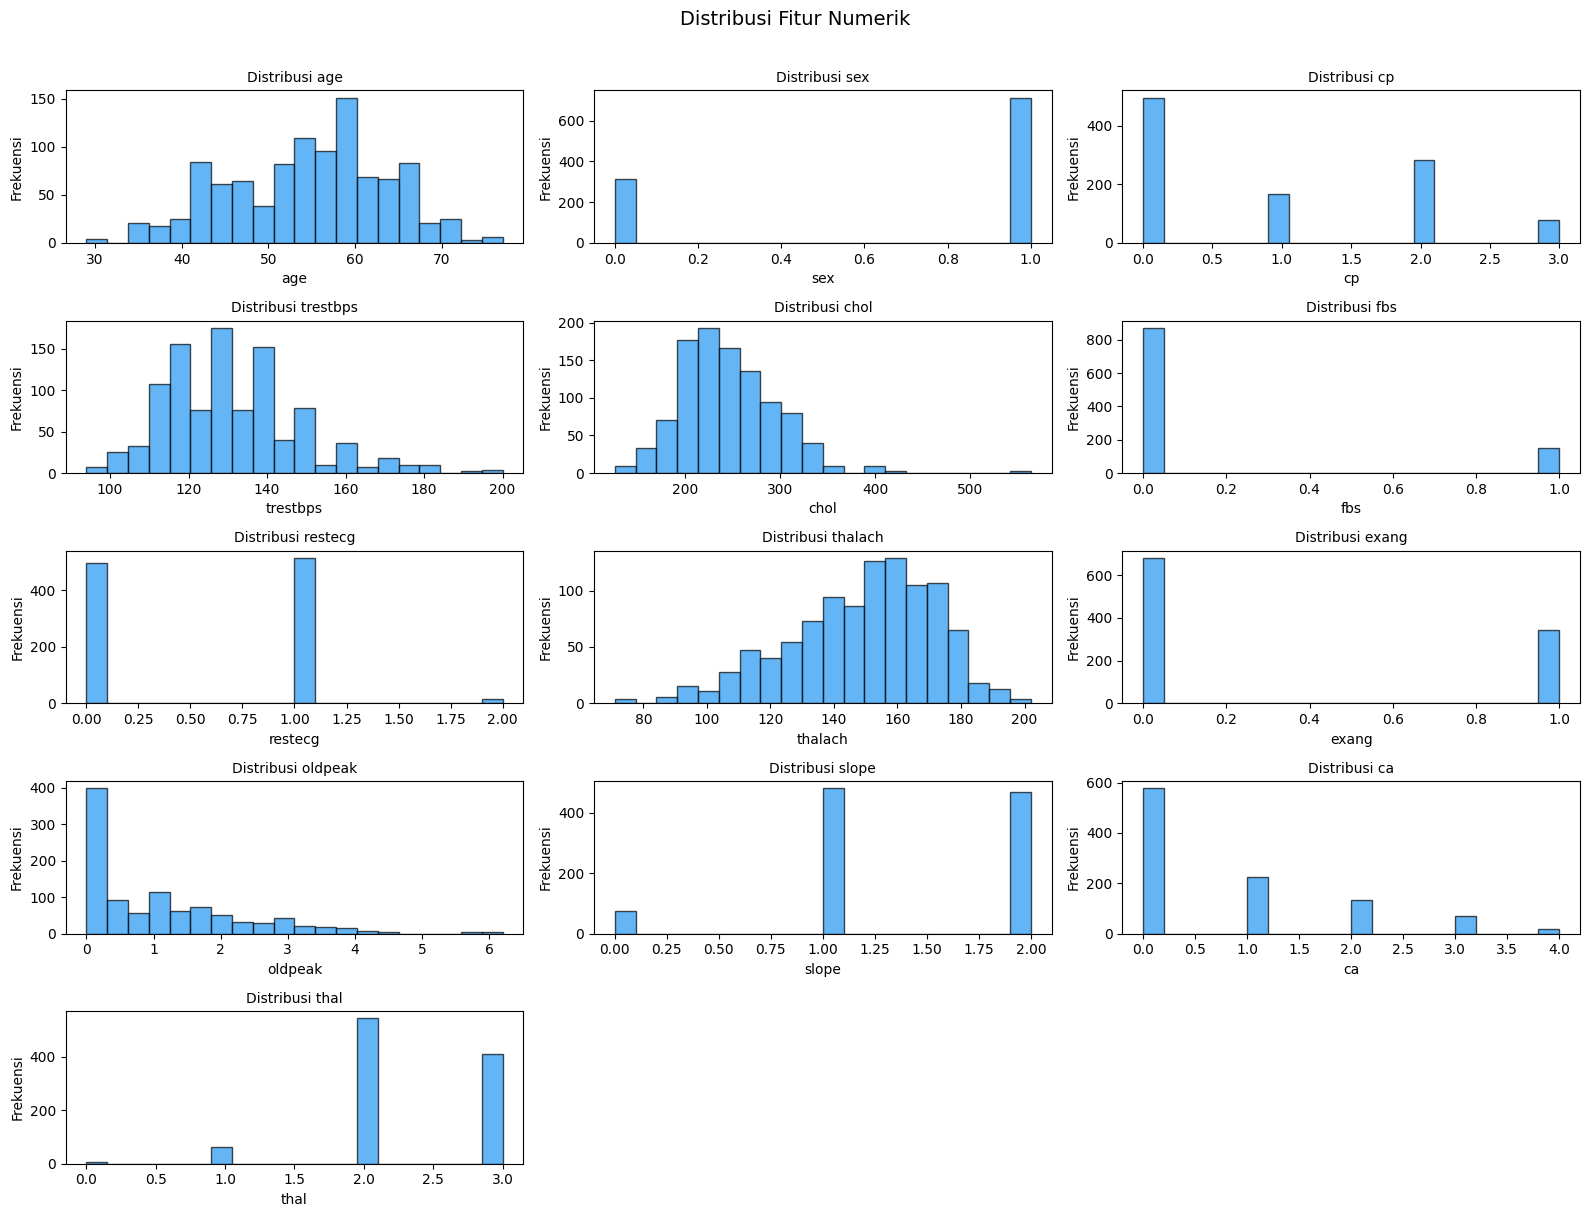

In [9]:
# Distribusi fitur numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'target']

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # otomatis hitung baris

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='#2196F3', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distribusi_fitur_numerik.png', dpi=100)
plt.show()

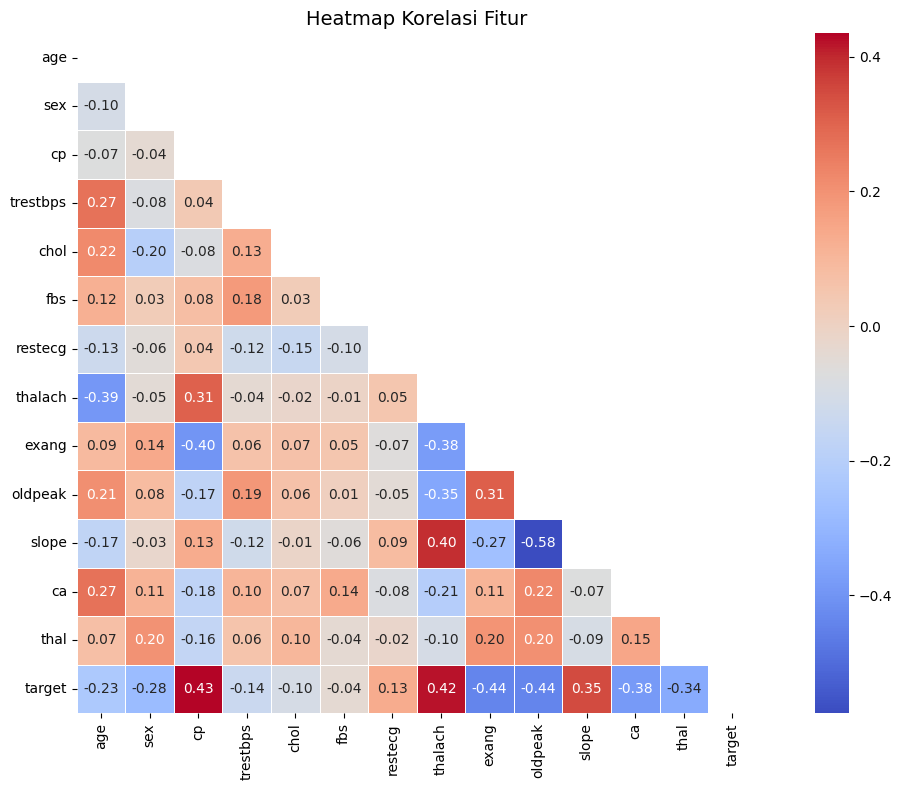

In [10]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=100)
plt.show()

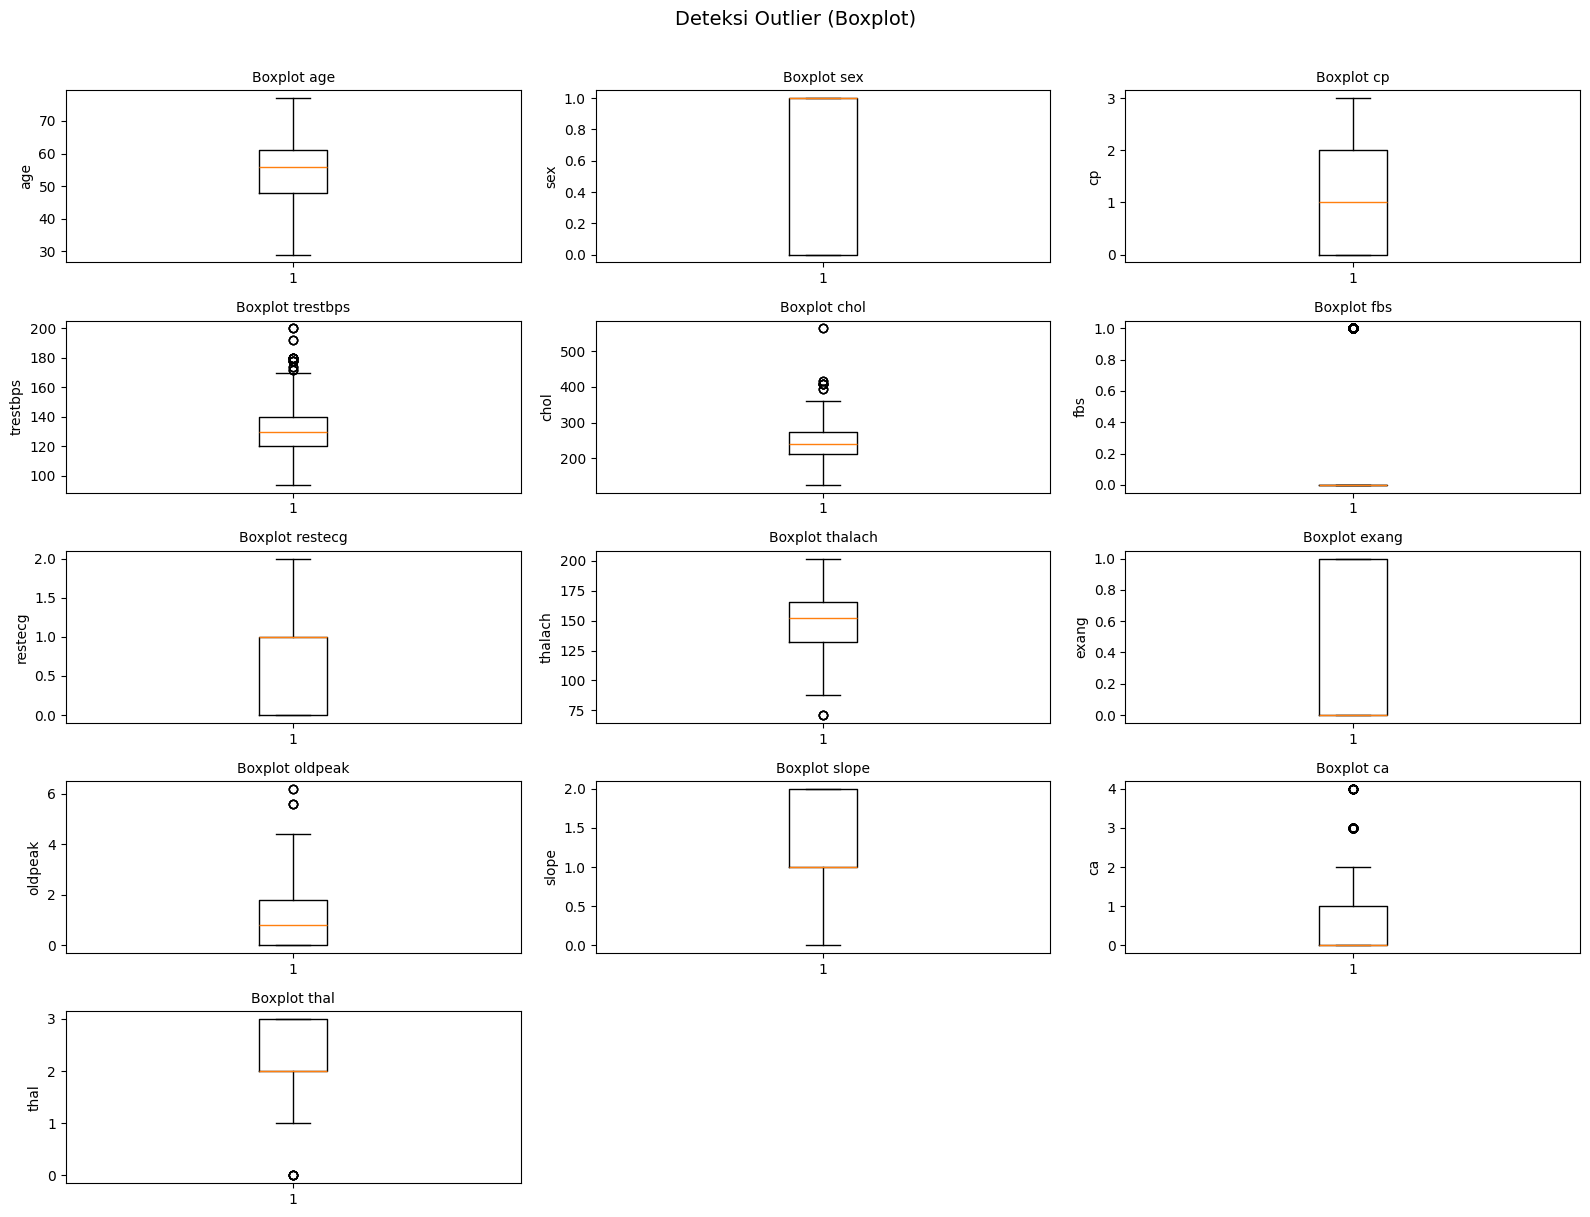

In [12]:
# Boxplot untuk deteksi outlier
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot {col}', fontsize=10)
    axes[i].set_ylabel(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=100)
plt.show()

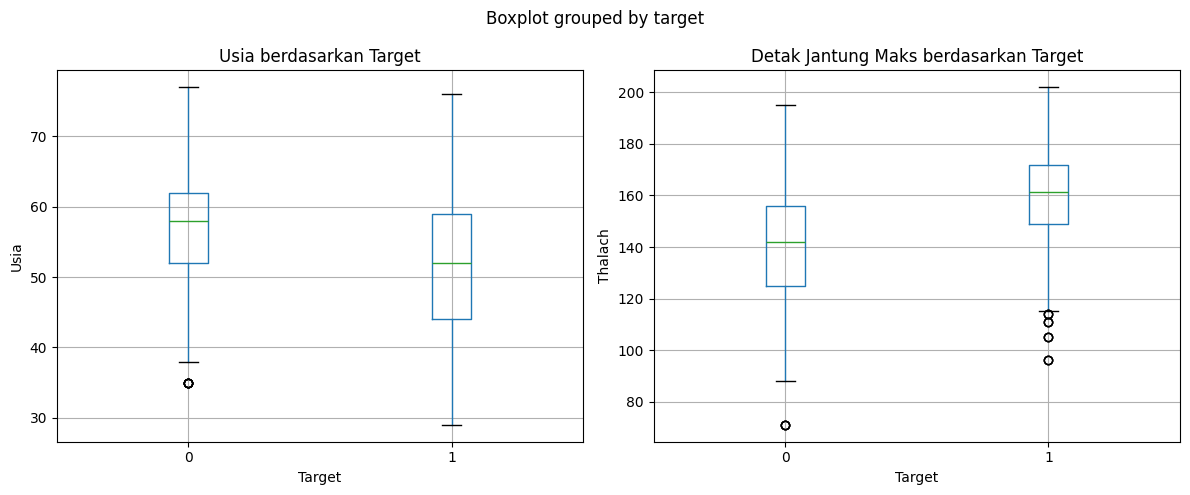

In [13]:
# Analisis fitur berdasarkan target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age vs target
df.boxplot(column='age', by='target', ax=axes[0])
axes[0].set_title('Usia berdasarkan Target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Usia')

# Thalach vs target
df.boxplot(column='thalach', by='target', ax=axes[1])
axes[1].set_title('Detak Jantung Maks berdasarkan Target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Thalach')

plt.tight_layout()
plt.savefig('analisis_fitur_target.png', dpi=100)
plt.show()

## 4. Preprocessing

In [14]:
# Salin dataframe
df_preprocessed = df.copy()

# 4.1 Hapus duplikat
n_before = len(df_preprocessed)
df_preprocessed = df_preprocessed.drop_duplicates()
n_after = len(df_preprocessed)
print(f'Duplikat dihapus: {n_before - n_after} baris')
print(f'Jumlah baris setelah hapus duplikat: {n_after}')

Duplikat dihapus: 723 baris
Jumlah baris setelah hapus duplikat: 302


In [15]:
# 4.2 Handle Missing Values
numerical_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'target']

# Impute dengan median untuk numerik
imputer = SimpleImputer(strategy='median')
df_preprocessed[numerical_cols] = imputer.fit_transform(df_preprocessed[numerical_cols])

print('Missing values setelah imputasi:')
print(df_preprocessed.isnull().sum().sum(), 'missing values tersisa')

Missing values setelah imputasi:
0 missing values tersisa


In [16]:
# 4.3 Penanganan Outlier dengan IQR
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    return df_clean

# Kolom numerik yang perlu ditangani outlier
outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
df_preprocessed = remove_outliers_iqr(df_preprocessed, outlier_cols)
print('Outlier berhasil ditangani dengan clipping IQR')

Outlier berhasil ditangani dengan clipping IQR


In [17]:
# 4.4 Feature Engineering
# Kolom kategorikal (one-hot encoding)
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
df_preprocessed = pd.get_dummies(df_preprocessed, columns=categorical_cols, drop_first=True)
print('One-hot encoding selesai')
print('Shape setelah encoding:', df_preprocessed.shape)

One-hot encoding selesai
Shape setelah encoding: (302, 23)


In [18]:
# 4.5 Pisahkan fitur dan target
X = df_preprocessed.drop('target', axis=1)
y = df_preprocessed['target']

# 4.6 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test: {X_test.shape}')

Ukuran X_train: (241, 22)
Ukuran X_test: (61, 22)


In [19]:
# 4.7 Feature Scaling
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
print('Feature scaling selesai')

Feature scaling selesai


In [20]:
# 4.8 Gabungkan kembali dan simpan hasil preprocessing
train_preprocessed = pd.concat([X_train, y_train], axis=1)
test_preprocessed = pd.concat([X_test, y_test], axis=1)

train_preprocessed.to_csv('heart_preprocessing/heart_train.csv', index=False)
test_preprocessed.to_csv('heart_preprocessing/heart_test.csv', index=False)

print('Dataset preprocessing berhasil disimpan!')
print(f'Train set: {train_preprocessed.shape}')
print(f'Test set: {test_preprocessed.shape}')

Dataset preprocessing berhasil disimpan!
Train set: (241, 23)
Test set: (61, 23)


## 5. Ringkasan Preprocessing

Berikut adalah tahapan preprocessing yang telah dilakukan:

1. **Data Loading** - Memuat dataset Heart Disease dari file CSV
2. **EDA** - Analisis distribusi, korelasi, dan outlier
3. **Hapus Duplikat** - Menghapus baris duplikat
4. **Handle Missing Values** - Imputasi dengan median
5. **Penanganan Outlier** - Clipping dengan metode IQR
6. **One-Hot Encoding** - Encoding kolom kategorikal
7. **Train-Test Split** - Proporsi 80:20 dengan stratified split
8. **Feature Scaling** - StandardScaler pada fitur numerik
9. **Simpan Dataset** - Menyimpan hasil preprocessing ke CSV